In [4]:
import matplotlib.pyplot as plt
import numpy as np
#%matplotlib inline
import pandas as pd
import scipy.optimize as so

## Overview

#### You have been assigned a transiting exoplanet with radial velocity data. Your job is to measure its mass and radius using simplistic RV and transit fit functions, and calculate its density. You will then compare it with the Solar System planets and discuss their similarilities and differences. 

$\textit{Disclaimer}$: the data and functions you will need to complete the majority of the project are provided but are not discussed in much detail. You will need to make sure you understand and are able to explain both. 

## Part 0: read in the planet data
Uncomment the name of your specific planet. Comment out all other planets that are not yours. Run the cell.

### Data sources:
**GJ 1214 b**: 
- RV data is the HARPS RV Time Series from Table 2 of [Cloutier+ 2021](https://iopscience.iop.org/article/10.3847/1538-3881/ac1584)
- Light curve data is from ??

**TOI-2109 b**: [Wong+ 2021](https://iopscience.iop.org/article/10.3847/1538-3881/ac26bd#ajac26bdt5)
- RV data is from Table 3 after correcting for the systemic radial velocity of the system.


**GJ 486 b**: [Trifonov+ 2021](https://www.science.org/doi/10.1126/science.abd7645) (see their supplementary materials)
- RV data is "WOLF437_MAROON-X_RED_SINGLEDATA.txt" 
- Light curve data is "Detrended_GJ486_Matern_GP_PDCSAP.dat" 


In [5]:
#planet = 'GJ1214b'   
planet = 'HD189733b'
#planet = 'TOI-2109b'
#planet = 'GJ486b' 
rv_data = pd.read_csv(f'./data/{planet}_RVC.csv')
lc_data = pd.read_csv(f'./data/{planet}_PLC.csv')

#dictionary containing the planets' orbital periods in days.
period = {
    'GJ1214b':1.58040433,
    'HD189733b': 2.21857567,
    'TOI-2109b': 0.672474140,
    'GJ486b': 1.467119
    }

## Part 1: measuring radial velocity semi-amplitude

In the cell below, we are going to fit the RV data in m/s to a sine function using the scipy.optimize.curve_fit function. Make sure you read through the documentation for this function to understand what technique(s) it is using for the curve fitting. The data file for your planet contains the absolute uncertainties (also in m/s) of each data point. I have not included these in the fit below, but the curve_fit function is capable of using data uncertainties to do a weighted fit. For some planets, including the RV uncertainties in the fit can make a big difference for the best fit for the RV semi-amplitude, especially if the uncertainties are large and the data is sparse. So, be careful here.

**All planets for this project were selected, in part, because their RV data are well approximated by a sine curve. You need to make sure you understand and are able to discuss the conditions that must be met for this to be the case.**



In [6]:
def sine_func(orb_phase, K, x0):
    return K*np.sin((orb_phase-x0)*2.0*np.pi)

params_rv, covariance_rv = so.curve_fit(sine_func, rv_data['orb_phase'], rv_data['RVel'])

params_rv, covariance_rv = so.curve_fit(sine_func, rv_data['orb_phase'], rv_data['RVel'], sigma = rv_data['RVel_err'])

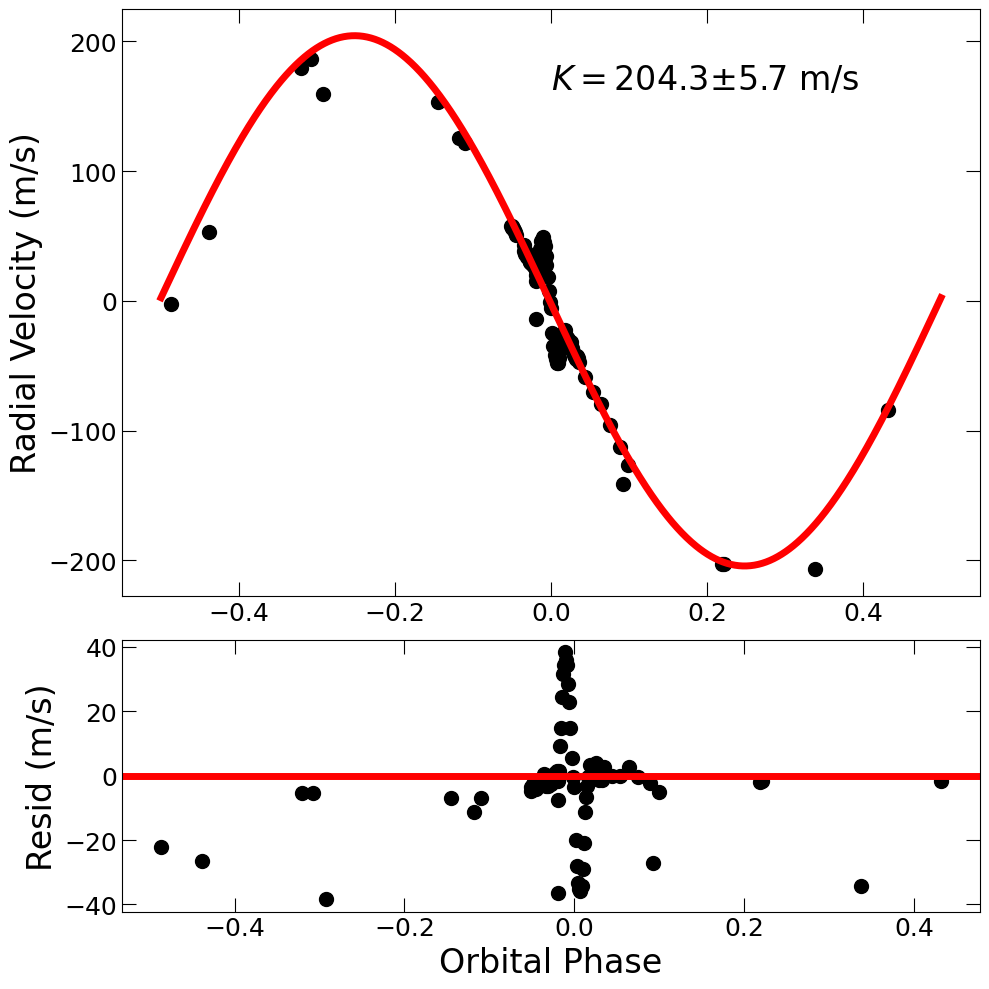

In [7]:
fig = plt.figure(figsize = (10,10))
ax1 = plt.subplot2grid((3, 2), (0, 0), colspan=2, rowspan = 2)
ax2 = plt.subplot2grid((3, 2), (2, 0), colspan=2, rowspan = 1)


ax1.plot(rv_data['orb_phase'], rv_data['RVel'], 'ko', markersize = 10)
x = np.linspace(-0.5, 0.5, 1000)
ax1.plot(x, sine_func(x, params_rv[0], params_rv[1]), 'r-', lw = 5)
ax1.text(0., 0.8*abs(params_rv[0]), r'$K = $' + str(round(abs(params_rv[0]), 1)) + r'$\pm$' +  str(round(covariance_rv[0,0]**0.5, 1))
         + ' m/s', fontsize = 24)
ax1.tick_params(which = 'both', direction = 'in', labelsize = 18, length = 10, top = True, right = True)
ax1.set_ylabel('Radial Velocity (m/s)', fontsize = 24)


ax2.plot(rv_data['orb_phase'], rv_data['RVel'] - sine_func(rv_data['orb_phase'], params_rv[0], params_rv[1]), 'ko', markersize = 10)
ax2.set_xlabel('Orbital Phase', fontsize = 24)
ax2.set_ylabel('Resid (m/s)', fontsize = 24)
ax2.tick_params(which = 'both', direction = 'in', labelsize = 18, length = 10, top = True, right = True)

ax2.axhline(0, color = 'r', lw = 5)

plt.tight_layout()

In [8]:
params_rv

array([-204.34882673,    0.99812311])

## Part 2: convert RV semi-amplitude to planet mass
1. Use the NASA Exoplanet Archive (NEA) and your notes to convert the semi-amplitude into a mass for the planet. 
2. Calculate the uncertainty in planet mass using standard propogation of uncertainties. 
    - You will need to consider the uncertainties in host star mass and semi-amplitude. You can neglect the uncertainties in semi major axis and/or orbital period for the sake of this calulcation. Why?      
3. Quantify how your results compare with literature values, and be able to discuss the potential sources of any differences.
    
$\textit{Other notes}$: when quoting the mass of your planet, give it in either Earth masses or Jupiter masses. Do not give the mass in kg, g, etc. because something like 10^24 kg is not something a human brain can make a whole lot of sense of, at least mine can't. On the other hand, human brains are much better at making comparisons! You should play around with the plot above and make it your own -- e.g., add some minor ticks, a title, annotations as needed, etc.
    

## Part 3: measuring transit depth from a light curve 

The cell below fits light curve data for your planet to Eq. 11 from [Carter+ 2008, ApJ](https://ui.adsabs.harvard.edu/abs/2008ApJ...689..499C/abstract). 

**Similar to modeling an RV curve as a sine function, Eq. 11 from Carter+ is an idealized approximation of a transit light curve. You need to make sure you understand and are able to discuss the assumptions that go the fitting function and under what conditions this approximation is wholly inadequate.**

In [12]:
def lc_model(time, f0, d, tau, T, tc):
    y = np.zeros(len(time))
    i = 0
    for t in time:
        if abs(t-tc) <= (T/2.0) - tau/2.0:
            y[i] = f0-d
        if (T/2.0 - tau/2.0 < abs(t-tc)) and (abs(t-tc) < T/2.0 + tau/2.0):
            y[i] = f0 - d + (d/tau)*(abs(t-tc) - T/2.0 + tau/2.0)
        if abs(t-tc) >= T/2.0 + tau/2.0:
            y[i] = f0
        i += 1
    return y

params_lc, cov_lc = so.curve_fit(lc_model,lc_data['orb_phase'], lc_data['norm_flux'], p0 = [1.0, 0.3, 0.01, 0.02, 0.0])

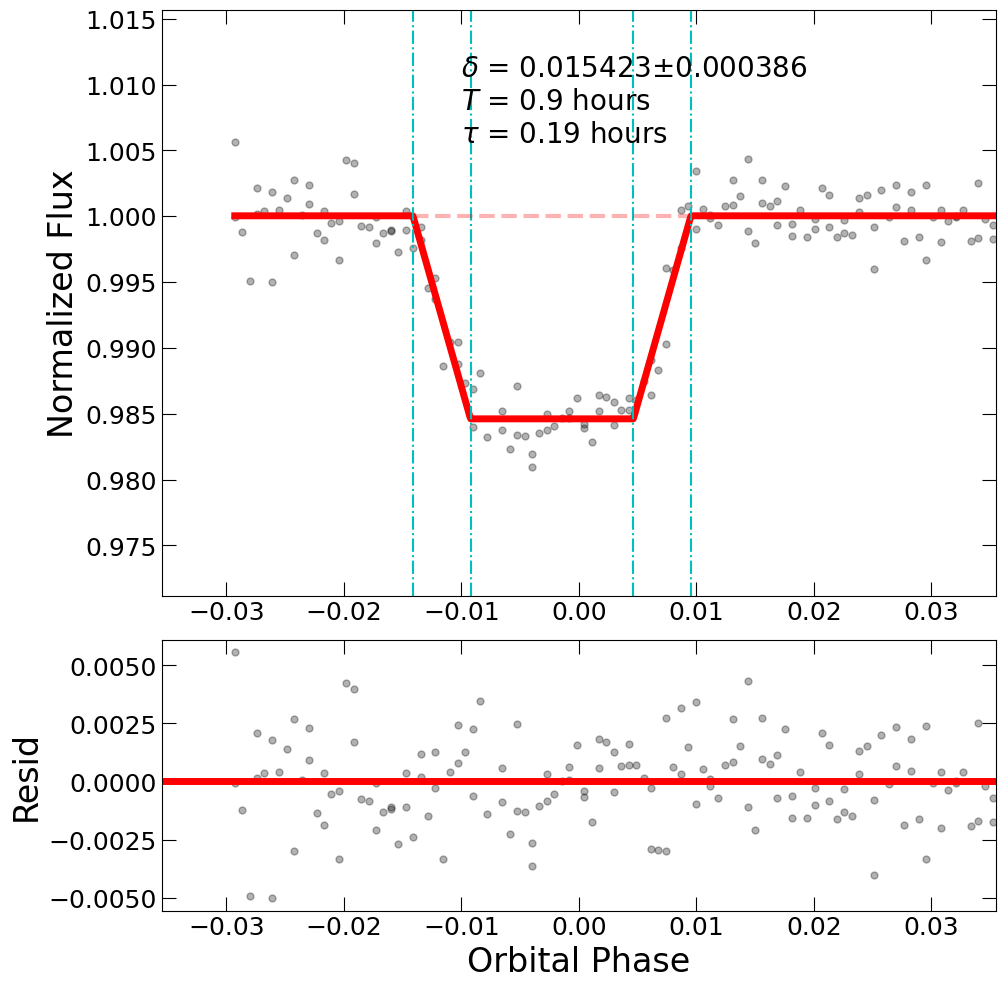

In [13]:
fig = plt.figure(figsize = (10,10))
ax1 = plt.subplot2grid((3, 2), (0, 0), colspan=2, rowspan = 2)
ax2 = plt.subplot2grid((3, 2), (2, 0), colspan=2, rowspan = 1)

ax1.plot(lc_data['orb_phase'], lc_data['norm_flux'], 'ko', markersize = 5, alpha = 0.3)

x = np.linspace(min(lc_data['orb_phase']), max(lc_data['orb_phase']), 1000)
ax1.plot(x, lc_model(x, params_lc[0], params_lc[1], params_lc[2], params_lc[3], params_lc[4]), 'r-', lw = 5)

ax1.tick_params(which = 'both', direction = 'in', labelsize = 18, length = 10, top = True, right = True)
ax1.set_ylabel('Normalized Flux', fontsize = 24)


ax1.axvline(params_lc[4]-params_lc[3]/2.0 - params_lc[2]/2.0, linestyle = '-.', color = 'c')
ax1.axvline(params_lc[4]-params_lc[3]/2.0 + params_lc[2]/2.0, linestyle = '-.', color = 'c')

ax1.axvline(params_lc[4] + params_lc[3]/2.0 + params_lc[2]/2.0, linestyle = '-.', color = 'c')
ax1.axvline(params_lc[4] + params_lc[3]/2.0 - params_lc[2]/2.0, linestyle = '-.', color = 'c')


ax1.plot([params_lc[4] - params_lc[3]/2.0 - params_lc[2]/2.0, params_lc[4] + (params_lc[3]/2.0) + params_lc[2]/2.0] , 
         [1.0, 1.0], color = 'red', ls = '--', lw = 3, alpha = 0.3)

ax1.text(-0.01, 1.005*max(lc_data['norm_flux']), r'$\delta$ = ' + str(round(params_lc[1], 6)) + r'$\pm$' 
         + str(round(cov_lc[1,1]**0.5, 6)), fontsize = 20)


ax1.text(-0.01,  1.0025*max(lc_data['norm_flux']), r'$T$ = ' + str(round((params_lc[3] + params_lc[2])*period[planet]*24.0, 2)) + ' hours', fontsize = 20)
ax1.text(-0.01,  1.0*max(lc_data['norm_flux']), r'$\tau$ = ' + str(round((params_lc[2])*period[planet]*24.0, 2)) + ' hours', fontsize = 20)


ax2.plot(lc_data['orb_phase'], lc_data['norm_flux'] - lc_model(lc_data['orb_phase'], params_lc[0], params_lc[1], params_lc[2], params_lc[3], params_lc[4]), 
         'ko', markersize = 5, alpha = 0.3)
ax2.tick_params(which = 'both', direction = 'in', labelsize = 18, length = 10, top = True, right = True)

ax2.set_xlabel('Orbital Phase', fontsize = 24)

ax1.set_xlim(-1.5*(params_lc[3] + params_lc[2]), 1.5*(params_lc[3] + params_lc[2]))
ax1.set_ylim(0.99*min(lc_data['norm_flux']), 1.01*max(lc_data['norm_flux']))

ax2.set_xlim(-1.5*(params_lc[3] + params_lc[2]), 1.5*(params_lc[3] + params_lc[2]))

ax2.set_ylabel('Resid', fontsize = 24)
ax2.axhline(0, color = 'r', lw = 5)

plt.tight_layout()


## Part 4: converting transit depth to planet radius
1. Use the NEA and your notes to convert the best-fit transit depth into the radius of your planet. 
2. Calculate the uncertainty in planet radius using standard propogation of uncertainties.    
    - You will need to consider the uncertainties in host star radius and transit depth. Which contributes more to the planet radius uncertainty? (quantify)    
3. Quantify how your results compare with literature values, and be able to discuss the potential sources of any differences.
    
$\textit{Other notes}$: quote the radius of the planet in either Earth radii or Jupiter radii (whichever makes more sense for a given planet). Do not give the mass in km, m, cm etc! 

## Part 5: Calculating planet density and comparing with the Solar System planets

1. Calculate the planet's density and corresponding uncertainty using the mass and radius values YOU calculated.
    - Here you can pick from many different units -- g/cc, kg/m$^3$ Earth densities, Jupiter densities, etc. -- and it's your job to decide what makes the most sense. Often, the most logical units to use are context dependent.
2. Compare your planet's density, mass, and radius with the Solar System planets. What type of planet do you think this is? Do we have any Solar System analogs?

## Part 6: choose your own adventure

Here you will and expand upon the project in a novel and/or insightful way, and build up your independent research skills in the process. This is an upper level course, so you are welcome and encouraged to dig as deep into a new topic as much as you want / as time allows. At a minimum, you will need to demonstrate you have done a decently thorough literature review on and have a deep understanding of (1) RV and/or light curve fitting, (2) a unique feature/quirk of your planet, or (3) the class/type of exoplanet that your planet belongs to and where said flavors of planets fit into the overall exoplanetary picture. 

Below are some ideas to get you thinking. **You can also define your own**. All research questions will differ in their time commitment and level of difficulty. As such, before launching into an idea, it is worth doing a bit of preliminary reading and creating an outline of what you think the various steps might be to get a sense of the timeline. 

Use EXOFAST or a similar package to do more sophisticated RV and transit curve fitting. The NEA has a nice EXOFAST interface. Discuss the differences between the results of the more sophisticated fitting procedure with the simpler ones presented in this notebook.

Measure the mass, radius, and density of another planet (cannot be GJ1214b, HD189733b, TOI-2109b, or GJ486b) and interpret it. Basically, do the project a second time with an additional planet. This may sound simple, but it will require a number of careful considerations when picking the planet. Further, you will have to find usable transit and radial velocity data, which will likely needed to be translated into orbital phase and/or normalized. If you go this route, first think about what kinds of planets will yield the largest transit depths and RV semi-amplitudes. Picking a few potential "large-signal" planets will make your search for good data much easier.

Make up your own new planet (keep it professional but otherwise have fun naming it). Simulate your own RV and light curve data for your new planet, incorporating realistic uncertainties (you'll need to justify your choices). Then try fitting your synthetic data and see how well the fit parameters reproduce the "true" values for your planet.

An alternative or expansion of the above idea is to do an RV or transit fitting sensitivity analysis. You can simulate RV and/or light curves for planets of different masses/radii, different detector noise levels, and/or different numbers of data points. How does a planet's inferred mass or radius change as a function of one or more of these considerations?


Specific to HD 189733:
- You should see some wonky residuals near orbital phase = 0. Try to figure out what this effect is called from the literature on this system and describe it qualitatively. It is caused by the planet transiting (a transit in an RV curve ... what?!). Convince yourself this is true: fit a sine function to these residuals to estimate the transit duration of the planet (and uncertainty). Compare this with the transit duration you calculated directly from the light curve. Depending on how good your fit is, the two numbers may not be exactly the same but they should agree to within ~ 10 minutes.
    
        
Specific to GJ 1214 b:
 
- Read up a bit on the radius gap (a topic we will cover later in the course). Make a radius-period plot all planets with all ~ R <= 2 R_earth planets on NEA. Add the radius gap from Van Eylen+ 2018 (https://ui.adsabs.harvard.edu/abs/2018MNRAS.479.4786V/abstract; coefficients given in point ii of the conclusions). Overlay GJ 1214 b clearly. Interpret and discuss the planet in the context of the radius gap.
 
Specific to TOI-2109b:

- The light curve data given for this planet used in Part 3 has been heavily processed such that we can get a reliable transit depth from the fitting function. However, in the [discovery paper](https://iopscience.iop.org/article/10.3847/1538-3881/ac26bd/pdf) for TOI-2109 b, you should notice that it has a quite complicated light curve. Namely, in addition to the planet transiting in front of the host, the light phase curve also has a quite nice "secondary eclipse". What is a secondary eclipse, what causes it, and what information can we glean from them? There is also noticable "phase-curve modulation" for this system. If you are feeling extra-ambitious, you can dig into phase curve modulations as well. This is an interesting, but quite dense topic in my (Joe) humble non-astronomer opinion. 


Specific to GJ486b:

- There are three GJ 486b-specific papers on the NEA. Together, they build a nice and quite straightforward story arc for this planet, involving some neat and timely topics that we will discuss but not hit heavily this semester. Basically, dig into the story of this planet and be able to describe the key points and why we should care. 

        
        
        